<a href="https://colab.research.google.com/github/aagneye-syam/Ensemble-Based-Deep-Learning-Framework-for-Radiotherapy-Dose-Prediction/blob/master/openkbp_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import sys
primary_directory = '/content/drive/My Drive/open-kbp-master'
sys.path.insert(0, primary_directory)

In [ ]:
!pip install pydicom
!pip install pynrrd
!pip install rt-utils

In [ ]:

import shutil
import pydicom
import nrrd
from tensorflow import keras as Ks
from keras.models import *
from keras.layers import *
from keras.optimizers import *
import os
import tensorflow.keras.backend as K
import pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
main_data_dir = '{}/provided-data'.format(primary_directory)
training_data_dir = '{}/train-pats'.format(main_data_dir)
validation_data_dir = '{}/validation-pats'.format(main_data_dir)
testing_data_dir = '{}/test-pats'.format(main_data_dir)

# Define hold out set
test_time = False  # Only change this to True when the model has been fully tuned on the validation set

# path where any data generated by this code (e.g., predictions, models) are stored
results_dir = '{}/results'.format(primary_directory)  # parent path where results are stored

In [ ]:
def load_file(file_name):
    """Load a file in one of the formats provided in the OpenKBP dataset
    :param file_name: the name of the file to be loaded
    :return: the file loaded
    """
    # Load the file as a csv
    loaded_file_df = pd.read_csv(file_name, index_col=0)
    # If the csv is voxel dimensions read it with numpy
    if 'voxel_dimensions.csv' in file_name:
        loaded_file = np.loadtxt(file_name)
    # Check if the data has any values
    elif loaded_file_df.isnull().values.any():
        # Then the data is a vector, which we assume is for a mask of ones
        loaded_file = np.array(loaded_file_df.index).squeeze()
    else:
        # Then the data is a matrix of indices and data points
        loaded_file = {'indices': np.array(loaded_file_df.index).squeeze(),
                       'data': np.array(loaded_file_df['data']).squeeze()}

    return loaded_file


def get_paths(directory_path, ext=''):
    """Get the paths of every file with a specified extension in a directory
    :param directory_path: the path of the directory of interest
    :param ext: the extensions of the files of interest
    :return: the path of all files of interest
    """
    # if dir_name doesn't exist return an empty array
    if not os.path.isdir(directory_path):
        return []
    # Otherwise dir_name exists and function returns contents name(s)
    else:
        all_image_paths = []
        # If no extension given, then get all files
        if ext == '':
            dir_list = os.listdir(directory_path)
            for iPath in dir_list:
                if '.' != iPath[0]:  # Ignore hidden files
                    all_image_paths.append('{}/{}'.format(directory_path, str(iPath)))
        else:
            # Get list of paths for files with the extension ext
            data_root = pathlib.Path(directory_path)
            for iPath in data_root.glob('*.{}'.format(ext)):
                all_image_paths.append(str(iPath))

    return all_image_paths


def get_paths_from_sub_directories(main_directory_path, sub_dir_list, ext=''):
    """Compiles a list of all paths within each sub directory listed in sub_dir_list that follows the main_dir_path
    :param main_directory_path: the path for the main directory of interest
    :param sub_dir_list: the name(s) of the directory of interest that are in the main_directory
    :param ext: the extension of the files of interest (in the usb directories)
    :return:
    """
    # Initialize list of paths
    path_list = []
    # Iterate through the sub directory names and build up the path list
    for sub_dir in sub_dir_list:
        paths_to_add = get_paths('{}/{}'.format(main_directory_path, sub_dir), ext=ext)
        path_list.extend(paths_to_add)

    return path_list


def sparse_vector_function(x, indices=None):
    """Convert a tensor into a dictionary of the non zero values and their corresponding indices
    :param x: the tensor or, if indices is not None, the values that belong at each index
    :param indices: the raveled indices of the tensor
    :return:  sparse vector in the form of a dictionary
    """
    if indices is None:
        y = {'data': x[x > 0], 'indices': np.nonzero(x.flatten())[-1]}
    else:
        y = {'data': x[x > 0], 'indices': indices[x > 0]}
    return y


def make_directory_and_return_path(dir_path):
    """Makes a directory only if it does not already exist
    :param dir_path: the path of the directory to be made
    :return: returns the directory path
    """
    os.makedirs(dir_path, exist_ok=True)

    return dir_path


def normalize_dicom(img):
    HOUNSFIELD_MIN = -1024
    HOUNSFIELD_MAX = 1500
    HOUNSFIELD_RANGE = 1000
    img[img < HOUNSFIELD_MIN] = HOUNSFIELD_MIN
    img[img > HOUNSFIELD_MAX] = HOUNSFIELD_MAX
    img = img / HOUNSFIELD_RANGE
    #if (HOUNSFIELD_RANGE!=0):
    #  img = ((img - HOUNSFIELD_MIN) / HOUNSFIELD_RANGE)
    #else:
    #  img = img - HOUNSFIELD_MIN
    return (img)

In [ ]:
class DataLoader:
    """Generates data for tensorflow"""

    def __init__(self, file_paths_list, batch_size=1, patient_shape=(128, 128, 128), shuffle=True,
                 mode_name='training_model'):
        """Initialize the DataLoader class, which loads the data for OpenKBP
        :param file_paths_list: list of the directories or single files where data for each patient is stored
        :param batch_size: the number of data points to lead in a single batch
        :param patient_shape: the shape of the patient data
        :param shuffle: whether or not order should be randomized
        """
        # Set file_loader specific attributes
        self.rois = dict(oars=['Brainstem', 'SpinalCord', 'RightParotid', 'LeftParotid',
                               'Esophagus', 'Larynx', 'Mandible'], targets=['PTV56', 'PTV63', 'PTV70'])

        self.batch_size = batch_size  # Number of patients to load in a single batch
        self.patient_shape = patient_shape  # Shape of the patient
        self.indices = np.arange(len(file_paths_list))  # Indices of file paths
        self.file_paths_list = file_paths_list  # List of file paths
        self.shuffle = shuffle  # Indicator as to whether or not data is shuffled
        self.full_roi_list = sum(map(list, self.rois.values()), [])  # make a list of all rois
        self.num_rois = len(self.full_roi_list)
        self.patient_id_list = ['pt_{}'.format(k.split('/pt_')[1].split('/')[0].split('.csv')[0]) for k in
                                self.file_paths_list]  # the list of patient ids with information in this data loader

        # Set files to be loaded
        self.required_files = None
        self.mode_name = mode_name  # Defines the mode for which data must be loaded for
        self.set_mode(self.mode_name)  # Set load mode to prediction by default

    def get_batch(self, index=None, patient_list=None):
        """Loads one batch of data
        :param index: the index of the batch to be loaded
        :param patient_list: the list of patients for which to load data for
        :return: a dictionary with the loaded data
        """

        if patient_list is None:
            # Generate batch based on the provided index
            indices = self.indices[index * self.batch_size:(index + 1) * self.batch_size]
        else:
            # Generate batch based on the request patients
            indices = self.patient_to_index(patient_list)

        # Make a list of files to be loaded
        file_paths_to_load = [self.file_paths_list[k] for k in indices]

        # Load the requested files as a tensors
        loaded_data = self.load_data(file_paths_to_load)
        return loaded_data

    def patient_to_index(self, patient_list):
        """Converts a list of patient ids to their appropriate indices
        :param patient_list: list of patient ids
        :return: list of indices for the requested patients
        """
        # Get the indices for the list that is not shuffled
        un_shuffled_indices = [self.patient_id_list.index(k) for k in patient_list]

        # Map the indices to the shuffled indices to the shuffled indices
        shuffled_indices = [self.indices[k] for k in un_shuffled_indices]

        return shuffled_indices

    def set_mode(self, mode_name, single_file_name=None):
        """Selects the type of data that is loaded
        :param mode_name: the name of the mode that the data loader is switching to
        :param single_file_name: the name of the file that should be loaded (only used if the mode_name is 'single_file')
        """
        self.mode_name = mode_name

        if mode_name == 'training_model':
            # The mode that should be used when training or validing a model
            self.required_files = {'dose': (self.patient_shape + (1,)),  # The shape of dose tensor
                                   'ct': (self.patient_shape + (1,)),  # The shape of ct tensor
                                   'structure_masks': (self.patient_shape + (self.num_rois,)),
                                   # The shape of the structure mask tensor
                                   'possible_dose_mask': (self.patient_shape + (1,)),
                                   # Mask of where dose can be deposited
                                   'voxel_dimensions': (3,)
                                   # Physical dimensions (in mm) of voxels
                                   }
        elif mode_name == 'dose_prediction':
            # The mode that should be used when training or validing a model
            self.required_files = {'ct': (self.patient_shape + (1,)),  # The shape of ct tensor
                                   'structure_masks': (self.patient_shape + (self.num_rois,)),
                                   # The shape of the structure mask tensor
                                   'possible_dose_mask': (self.patient_shape + (1,)),
                                   # Mask of where dose can be deposited
                                   'voxel_dimensions': (3,)  # Physical dimensions (in mm) of voxels
                                   }
            self.batch_size = 1
            print('Warning: Batch size has been changed to 1 for dose prediction mode')

        elif mode_name == 'predicted_dose':
            # This mode loads a single feature (e.g., dose, masks for all structures)
            self.required_files = {mode_name: (self.patient_shape + (1,))}  # The shape of a dose tensor

        elif mode_name == 'evaluation':
            # The mode that should be used evaluate the quality of predictions
            self.required_files = {'dose': (self.patient_shape + (1,)),  # The shape of dose tensor
                                   'structure_masks': (self.patient_shape + (self.num_rois,)),
                                   'voxel_dimensions': (3,),  # Physical dimensions (in mm) of voxels
                                   'possible_dose_mask': (self.patient_shape + (1,)),
                                   }
            self.batch_size = 1
            print('Warning: Batch size has been changed to 1 for evaluation mode')

        else:
            print('Mode does not exist. Please re-run with either \'training_model\', \'prediction\', '
                  '\'predicted_dose\', or \'evaluation\'')

    def number_of_batches(self):
        """Calculates how many full batches can be made in an epoch
        :return: the number of batches that can be loaded
        """
        return int(np.floor(len(self.file_paths_list) / self.batch_size))

    def on_epoch_end(self):
        """Randomizes the indices after each epoch"""
        if self.shuffle:
            np.random.shuffle(self.indices)

    def load_data(self, file_paths_to_load):
        """Generates data containing batch_size samples X : (n_samples, *dim, n_channels)
        :param file_paths_to_load: the paths of the files to be loaded
        :return: a dictionary of all the loaded files
        """

        # Initialize dictionary for loaded data and lists to track patient path and ids
        tf_data = {}.fromkeys(self.required_files)
        patient_list = []
        patient_path_list = []

        # Loop through each key in tf data to initialize the tensor with zeros
        for key in tf_data:
            # Make dictionary with appropriate data sizes for bath learning
            tf_data[key] = np.zeros((self.batch_size, *self.required_files[key]))

        # Generate data
        for i, pat_path in enumerate(file_paths_to_load):
            # Get patient ID and location of processed data to load
            patient_path_list.append(pat_path)
            pat_id = pat_path.split('/')[-1].split('.')[0]
            patient_list.append(pat_id)
            # Make a dictionary of all the tensors
            loaded_data_dict = self.load_and_shape_data(pat_path)
            # Iterate through the dictionary add the loaded data to the "batch channel"
            for key in tf_data:
                tf_data[key][i,] = loaded_data_dict[key]

        # Add two keys to the tf_data dictionary to track patient information
        tf_data['patient_list'] = patient_list
        tf_data['patient_path_list'] = patient_path_list

        return tf_data

    def load_and_shape_data(self, path_to_load):
        """ Reshapes data that is stored as vectors into matrices
        :param path_to_load: the path of the data that needs to be loaded. If the path is a directory, all data in the
         directory will be loaded. If path is a file then only that file will be loaded.
        :return: Loaded data with the appropriate shape
        """

        # Initialize the dictionary for the loaded files
        loaded_file = {}
        if '.csv' in path_to_load:
            loaded_file[self.mode_name] = load_file(path_to_load)
        else:
            files_to_load = get_paths(path_to_load, ext='')
            # Load files and get names without file extension or directory
            for f in files_to_load:
                f_name = f.split('/')[-1].split('.')[0]
                if f_name in self.required_files or f_name in self.full_roi_list:
                    loaded_file[f_name] = load_file(f)

        # Initialize matrices for features
        shaped_data = {}.fromkeys(self.required_files)
        for key in shaped_data:
            shaped_data[key] = np.zeros(self.required_files[key])

        # Populate matrices that were no initialized as []
        for key in shaped_data:
            if key == 'structure_masks':
                # Convert dictionary of masks into a tensor (necessary for tensorflow)
                for roi_idx, roi in enumerate(self.full_roi_list):
                    if roi in loaded_file.keys():
                        np.put(shaped_data[key], self.num_rois * loaded_file[roi] + roi_idx, int(1))
            elif key == 'possible_dose_mask':
                np.put(shaped_data[key], loaded_file[key], int(1))
            elif key == 'voxel_dimensions':
                shaped_data[key] = loaded_file[key]
            else:  # Files with shape
                np.put(shaped_data[key], loaded_file[key]['indices'], loaded_file[key]['data'])

        return shaped_data


In [ ]:
class My_generator(Ks.utils.Sequence):

  def __init__(self, data_load, num_files, batch_size):
    self.DataLoader = data_load
    self.num_files = num_files
    self.batch_size = batch_size

  def __len__(self):
    return (np.ceil(len(self.num_files)/float(self.batch_size))).astype(np.int)

  def __get_item__(self, id):
    #print(id)
    ct = []
    mask = []
    dose = []
    batch_data = self.DataLoader.get_batch(id)
    #ct.append(normalize_dicom(batch_data['ct']))
    ct.append(batch_data['ct'])
    mask.append(batch_data['structure_masks'])
    #dose.append(normalize_dicom(batch_data['dose']))
    dose.append(batch_data['dose'])
    #ct.append(batch_data['ct'])
    #dose.append(batch_data['dose'])
    ct = np.array(ct)
    mask = np.array(mask)
    dose = np.array(dose)
    #dose = dose / 70
    ct = ct.reshape(128,128,128,1)
    mask = mask.reshape(128,128,128,10)
    input = concatenate([ct, mask])
    dose = dose.reshape(128,128,128,1)
    #print(input.shape)
    #print(ct.shape)
    return input, dose


In [ ]:
batch_size = 1
test_plan_paths = get_paths(testing_data_dir, ext='')
num_test = len(test_plan_paths)
data_test = DataLoader(test_plan_paths)
test_gen = My_generator(data_test, num_test, batch_size)

test_ct = []
test_dose=[]
test_mask=[]
input = []
batch_data=DataLoader.get_batch(data_test,65)
test_ct.append(batch_data['ct'].reshape(128,128,128,1))
#test_ct.append(batch_data['ct'].reshape(128,128,128,1))
test_dose.append(batch_data['dose'].reshape(128,128,128,1))
test_mask.append(batch_data['structure_masks'].reshape(128,128,128,10))

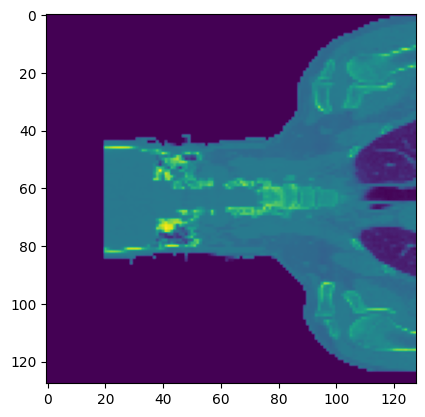

In [ ]:
plt.imshow(batch_data['ct'][0][68].reshape(128,128))


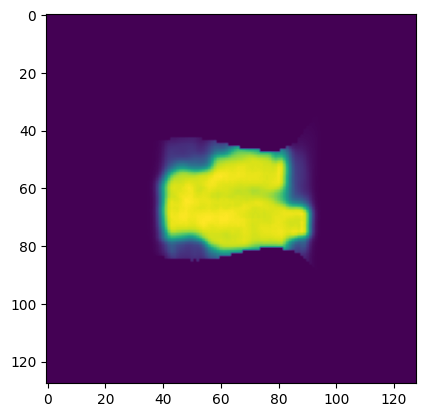

In [ ]:
plt.imshow(batch_data['dose'][0][60].reshape(128,128))


In [ ]:
test_mask=np.array(test_mask)
print(test_mask.shape)
test_mask = test_mask.reshape(128,128,128,10)
print(test_mask.shape)
test_mask = np.transpose(test_mask,(3,0,1,2))
print(test_mask.shape)

(1, 128, 128, 128, 10)
(128, 128, 128, 10)
(10, 128, 128, 128)


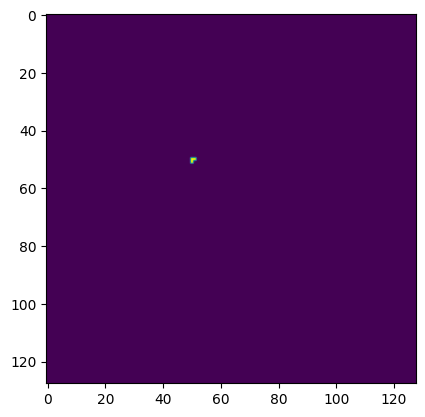

In [ ]:
plt.imshow(test_mask[6][60].reshape(128,128))
